Total: 5572 | Ham: 4825 | Spam: 747

Accuracy: 97.13%


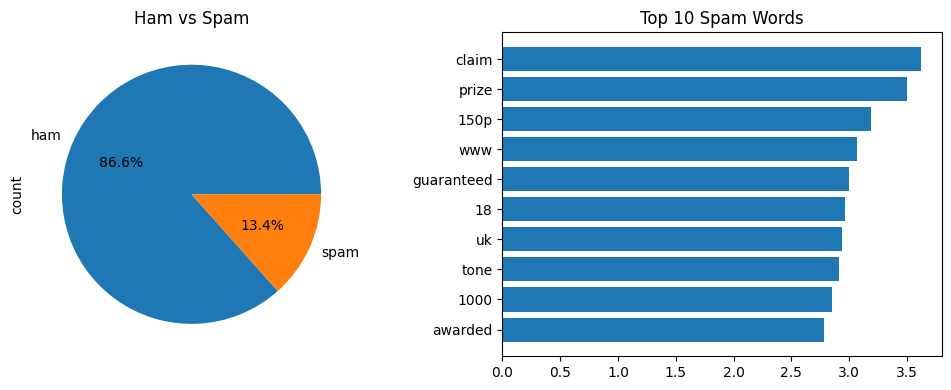


'Free prize! Claim now!...' → SPAM

'Hey, meeting at 3pm tomorrow...' → HAM

'You won $1000! Click here...' → SPAM


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

path = r"C:\Users\Admin\Downloads\SpamBase (1)\spambase.csv"
df = pd.read_csv(url, sep='\t', names=['label', 'message'])
print(f"Total: {len(df)} | Ham: {sum(df['label']=='ham')} | Spam: {sum(df['label']=='spam')}")

df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

X_train, X_test, y_train, y_test = train_test_split(
    df['message'],
    df['label_num'],
    test_size=0.2,
    random_state=43
)

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

model = MultinomialNB()

model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

print(f"\nAccuracy: {(y_pred == y_test).mean():.2%}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df['label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    ax=axes[0]
)

axes[0].set_title('Ham vs Spam')

feature_names = tfidf.get_feature_names_out()

spam_score = model.feature_log_prob_[1, :] - model.feature_log_prob_[0, :]

top_idx = spam_score.argsort()[-10:]

axes[1].barh(range(10), spam_score[top_idx])

axes[1].set_yticks(range(10))

axes[1].set_yticklabels([feature_names[i] for i in top_idx])

axes[1].set_title('Top 10 Spam Words')

plt.tight_layout()

plt.show()

test_messages = [
    "Free prize! Claim now!",
    "Hey, meeting at 3pm tomorrow",
    "You won $1000! Click here"
]

for msg in test_messages:
    vec = tfidf.transform([msg])
    pred = model.predict(vec)[0]
    print(f"\n'{msg[:30]}...' → {'SPAM' if pred == 1 else 'HAM'}")